# View Test Results

This notebook loads and compares the original vs new code outputs from test scripts.

**Test outputs saved:**
- Panel (original and new): `bgn_999_panel_original.pkl` and `bgn_999_panel_new.pkl`
- Moments (original and new): `bgn_0_moments_original.pkl` and `bgn_0_moments_new.pkl`
- Fama (original and new): `{model}_0_fama_original.pkl` and `{model}_0_fama_new.pkl`
- DKKM (original and new): `{model}_0_dkkm_{nfeatures}_original.pkl` and `{model}_0_dkkm_{nfeatures}_new.pkl`
- IPCA (original and new): `{model}_0_ipca_{K}_original.pkl` and `{model}_0_ipca_{K}_new.pkl`

In [12]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
np.set_printoptions(precision=6, suppress=True)

## Helper Functions

In [13]:
def load_pickle(filename):
    """Load a pickle file from current directory."""
    filepath = Path(filename)
    if not filepath.exists():
        print(f"File not found: {filename}")
        return None
    
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    print(f"Loaded {filename}")
    return data


def compare_arrays(arr1, arr2, name="arrays", rtol=1e-12, atol=1e-14):
    """Compare two arrays and report differences."""
    if arr1 is None or arr2 is None:
        print(f"{name}: One or both arrays are None")
        return
    
    arr1 = np.asarray(arr1)
    arr2 = np.asarray(arr2)
    
    if arr1.shape != arr2.shape:
        print(f"{name}: Shape mismatch - {arr1.shape} vs {arr2.shape}")
        return
    
    diff = np.abs(arr1 - arr2)
    max_diff = np.max(diff)
    mean_diff = np.mean(diff)
    
    rel_diff = diff / (np.abs(arr1) + 1e-20)
    max_rel_diff = np.max(rel_diff)
    
    is_close = np.allclose(arr1, arr2, rtol=rtol, atol=atol)
    
    print(f"{name}:")
    print(f"  Shape: {arr1.shape}")
    print(f"  Max absolute diff: {max_diff:.2e}")
    print(f"  Mean absolute diff: {mean_diff:.2e}")
    print(f"  Max relative diff: {max_rel_diff:.2e}")
    print(f"  Arrays equal (rtol={rtol}, atol={atol}): {is_close}")
    
    if not is_close:
        n_diff = np.sum(~np.isclose(arr1, arr2, rtol=rtol, atol=atol))
        print(f"  Number of different elements: {n_diff} / {arr1.size}")


def inspect_panel(panel_data):
    """Inspect panel data structure."""
    if 'panel' in panel_data:
        panel = panel_data['panel']
        print(f"Panel shape: {panel.shape}")
        print(f"\nColumns: {list(panel.columns)}")
        print(f"\nFirst few rows:")
        display(panel.head(10))
        print(f"\nSummary statistics:")
        display(panel.describe())
    
    if 'arr_tuple' in panel_data:
        arrays = panel_data['arr_tuple']
        print(f"\n\nArray tuple contains {len(arrays)} elements:")
        array_names = ['r', 'mu', 'xi', 'sigmaj', 'chi', 'beta', 'corr_zj', 
                       'eret', 'ret', 'P', 'corr_zr', 'book', 'op_cash_flow',
                       'loadings_mu_taylor', 'loadings_xi_taylor',
                       'loadings_mu_proj', 'loadings_xi_proj']
        for i, (name, arr) in enumerate(zip(array_names[:len(arrays)], arrays)):
            if isinstance(arr, np.ndarray):
                print(f"  [{i}] {name:<25} shape: {arr.shape}")
            else:
                print(f"  [{i}] {name:<25} scalar: {arr}")


def inspect_moments(moments_data):
    """Inspect moments data structure."""
    print(f"N: {moments_data.get('N', 'N/A')}")
    print(f"Start month: {moments_data.get('start_month', 'N/A')}")
    print(f"End month: {moments_data.get('end_month', 'N/A')}")
    print(f"Panel ID: {moments_data.get('panel_id', 'N/A')}")
    
    if 'moments' in moments_data:
        moments = moments_data['moments']
        print(f"\nMoments dict has {len(moments)} months")
        
        # Show first month as example
        first_month = min(moments.keys())
        print(f"\nExample month {first_month}:")
        for key, val in moments[first_month].items():
            if isinstance(val, np.ndarray):
                print(f"  {key}: shape {val.shape}")
            else:
                print(f"  {key}: {val}")


def inspect_fama(fama_data):
    """Inspect Fama data structure."""
    if 'ff_returns' in fama_data:
        ff = fama_data['ff_returns']
        print(f"Fama-French returns shape: {ff.shape}")
        print(f"First few months:")
        print(ff[:5])
    
    if 'fm_returns' in fama_data:
        fm = fama_data['fm_returns']
        print(f"\nFama-MacBeth returns shape: {fm.shape}")
        print(f"First few months:")
        print(fm[:5])


def inspect_dkkm(dkkm_data):
    """Inspect DKKM data structure."""
    if 'factors_rs' in dkkm_data:
        f_rs = dkkm_data['factors_rs']
        print(f"DKKM factors (rank standardized) shape: {f_rs.shape}")
        print(f"First few months:")
        print(f_rs[:5])
    
    if 'factors_nors' in dkkm_data:
        f_nors = dkkm_data['factors_nors']
        print(f"\nDKKM factors (no rank standardization) shape: {f_nors.shape}")
        print(f"First few months:")
        print(f_nors[:5])
    
    if 'W' in dkkm_data:
        W = dkkm_data['W']
        print(f"\nW matrix shape: {W.shape}")
    
    if 'rank_standardize' in dkkm_data:
        print(f"\nRank standardize: {dkkm_data['rank_standardize']}")


def inspect_ipca(ipca_data):
    """Inspect IPCA data structure."""
    if 'factor_returns' in ipca_data:
        factors = ipca_data['factor_returns']
        print(f"IPCA factor returns dict has {len(factors)} months")
        
        # Show first month as example
        first_month = min(factors.keys())
        print(f"\nExample month {first_month}:")
        print(f"  Shape: {factors[first_month].shape}")
        print(f"  Values: {factors[first_month]}")
    
    if 'test_months' in ipca_data:
        print(f"\nTest months: {ipca_data['test_months']}")

## Load and Compare Panel Data

In [14]:
# Load panel files
panel_original = load_pickle('bgn_999_panel_original.pkl')
panel_new = load_pickle('bgn_999_panel_new.pkl')

Loaded bgn_999_panel_original.pkl
Loaded bgn_999_panel_new.pkl


In [15]:
# Inspect original panel
if panel_original is not None:
    print("=" * 70)
    print("ORIGINAL PANEL")
    print("=" * 70)
    inspect_panel(panel_original)

ORIGINAL PANEL
Panel shape: (20000, 15)

Columns: ['month', 'firmid', 'mve', 'xret', 'A_1_taylor', 'A_2_taylor', 'A_1_proj', 'A_2_proj', 'roe', 'bm', 'mom', 'agr', 'f_mu_true', 'f_xi_true', 'rf_stand']

First few rows:


,month,firmid,mve,xret,A_1_taylor,A_2_taylor,A_1_proj,A_2_proj,roe,bm,mom,agr,f_mu_true,f_xi_true,rf_stand
14950,300,0,5.888630,0.075813,0.004609,-0.031208,0.009487,-0.033479,0.020032,0.849094,0.235745,0.000000,1.941985,-1.344094,0.015031
14951,300,1,4.006746,0.079376,0.006226,-0.031741,0.020742,-0.035850,0.045555,0.998316,0.220754,0.000000,1.941985,-1.344094,0.015031
14952,300,2,3.952203,0.157351,0.005691,-0.031657,0.021645,-0.036026,0.058418,1.012094,0.170069,0.000000,1.941985,-1.344094,0.015031
14953,300,3,11.301764,0.048311,0.001195,-0.030351,0.006256,-0.032527,0.029546,0.796336,0.165086,0.000000,1.941985,-1.344094,0.015031
14954,300,4,6.359108,0.082537,0.005617,-0.031349,0.016252,-0.034623,0.024806,0.943529,0.386599,0.000000,1.941985,-1.344094,0.015031
14955,300,5,7.797181,0.082997,0.005660,-0.031267,0.013339,-0.033971,0.022903,0.897760,0.101730,0.000000,1.941985,-1.344094,0.015031
14956,300,6,6.379003,0.058086,0.005440,-0.031316,0.016384,-0.034644,0.024785,0.940586,-0.007394,0.000000,1.941985,-1.344094,0.015031
14957,300,7,8.702216,0.053946,0.002088,-0.030591,0.007404,-0.032854,0.030181,0.804393,0.255693,0.000000,1.941985,-1.344094,0.015031
14958,300,8,3.164279,0.083753,0.006826,-0.032053,0.016717,-0.035443,0.031475,0.948083,-0.098765,0.000000,1.941985,-1.344094,0.015031
14959,300,9,9.964765,0.066168,0.000988,-0.030350,0.007176,-0.026576,0.016455,0.802829,0.213081,0.142857,1.941985,-1.344094,0.015031



Summary statistics:


,month,firmid,mve,xret,A_1_taylor,A_2_taylor,A_1_proj,A_2_proj,roe,bm,mom,agr,f_mu_true,f_xi_true,rf_stand
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,499.500000,24.500000,9.160309,0.011890,0.005916,-0.031671,0.018024,-0.034239,0.025643,0.925996,0.194956,0.002088,0.400265,-0.122017,-0.172404
std,115.472580,14.431230,3.771246,0.077442,0.001837,0.000662,0.005584,0.002321,0.062265,0.131676,0.284175,0.058213,0.986806,1.019734,0.422900
min,300.000000,0.000000,1.029156,-0.506327,-0.000549,-0.036992,-0.006880,-0.066121,0.000188,0.466961,-0.712410,-0.500000,-2.532681,-3.438583,-0.960383
25%,399.750000,12.000000,6.358984,-0.014682,0.004780,-0.032043,0.014335,-0.035301,0.008643,0.835977,0.036527,0.000000,-0.295111,-0.802596,-0.501930
50%,499.500000,24.500000,8.767764,0.012906,0.005975,-0.031631,0.018125,-0.034167,0.015041,0.908950,0.170366,0.000000,0.399738,-0.154550,-0.180217
75%,599.250000,37.000000,11.380556,0.040533,0.007073,-0.031244,0.021511,-0.033034,0.027004,0.998689,0.314146,0.000000,0.973748,0.474085,0.081758
max,699.000000,49.000000,27.363888,5.059813,0.013814,-0.029212,0.046121,-0.008669,5.679952,1.588760,8.602666,1.000000,4.175141,3.186295,1.222081




Array tuple contains 17 elements:
  [0] r                         shape: (701,)
  [1] mu                        shape: (700,)
  [2] xi                        shape: (700,)
  [3] sigmaj                    shape: (699, 50)
  [4] chi                       shape: (700, 700, 50)
  [5] beta                      shape: (700, 50)
  [6] corr_zj                   shape: (699, 50)
  [7] eret                      shape: (700, 50)
  [8] ret                       shape: (700, 50)
  [9] P                         shape: (701, 50)
  [10] corr_zr                   scalar: -0.175
  [11] book                      shape: (700, 50)
  [12] op_cash_flow              shape: (699, 50)
  [13] loadings_mu_taylor        shape: (700, 50)
  [14] loadings_xi_taylor        shape: (700, 50)
  [15] loadings_mu_proj          shape: (700, 50)
  [16] loadings_xi_proj          shape: (700, 50)


In [16]:
# Inspect new panel
if panel_new is not None:
    print("=" * 70)
    print("NEW PANEL")
    print("=" * 70)
    inspect_panel(panel_new)

NEW PANEL
Panel shape: (20000, 14)

Columns: ['month', 'firmid', 'mve', 'xret', 'A_1_taylor', 'A_2_taylor', 'A_1_proj', 'A_2_proj', 'roe', 'bm', 'mom', 'agr', 'rf_stand', 'size']

First few rows:


,month,firmid,mve,xret,A_1_taylor,A_2_taylor,A_1_proj,A_2_proj,roe,bm,mom,agr,rf_stand,size
14950,300,0,5.888630,0.075813,0.004609,-0.031208,0.009487,-0.033479,0.020032,0.849094,0.235745,0.000000,0.015031,1.773023
14951,300,1,4.006746,0.079376,0.006226,-0.031741,0.020742,-0.035850,0.045555,0.998316,0.220754,0.000000,0.015031,1.387979
14952,300,2,3.952203,0.157351,0.005691,-0.031657,0.021645,-0.036026,0.058418,1.012094,0.170069,0.000000,0.015031,1.374273
14953,300,3,11.301764,0.048311,0.001195,-0.030351,0.006256,-0.032527,0.029546,0.796336,0.165086,0.000000,0.015031,2.424959
14954,300,4,6.359108,0.082537,0.005617,-0.031349,0.016252,-0.034623,0.024806,0.943529,0.386599,0.000000,0.015031,1.849888
14955,300,5,7.797181,0.082997,0.005660,-0.031267,0.013339,-0.033971,0.022903,0.897760,0.101730,0.000000,0.015031,2.053762
14956,300,6,6.379003,0.058086,0.005440,-0.031316,0.016384,-0.034644,0.024785,0.940586,-0.007394,0.000000,0.015031,1.853012
14957,300,7,8.702216,0.053946,0.002088,-0.030591,0.007404,-0.032854,0.030181,0.804393,0.255693,0.000000,0.015031,2.163578
14958,300,8,3.164279,0.083753,0.006826,-0.032053,0.016717,-0.035443,0.031475,0.948083,-0.098765,0.000000,0.015031,1.151925
14959,300,9,9.964765,0.066168,0.000988,-0.030350,0.007176,-0.026576,0.016455,0.802829,0.213081,0.142857,0.015031,2.299055



Summary statistics:


,month,firmid,mve,xret,A_1_taylor,A_2_taylor,A_1_proj,A_2_proj,roe,bm,mom,agr,rf_stand,size
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,499.500000,24.500000,9.160309,0.011890,0.005916,-0.031671,0.018024,-0.034239,0.025643,0.925996,0.194956,0.002088,-0.172404,2.124524
std,115.472580,14.431230,3.771246,0.077442,0.001837,0.000662,0.005584,0.002321,0.062265,0.131676,0.284175,0.058213,0.422900,0.441227
min,300.000000,0.000000,1.029156,-0.506327,-0.000549,-0.036992,-0.006880,-0.066121,0.000188,0.466961,-0.712410,-0.500000,-0.960383,0.028739
25%,399.750000,12.000000,6.358984,-0.014682,0.004780,-0.032043,0.014335,-0.035301,0.008643,0.835977,0.036527,0.000000,-0.501930,1.849869
50%,499.500000,24.500000,8.767764,0.012906,0.005975,-0.031631,0.018125,-0.034167,0.015041,0.908950,0.170366,0.000000,-0.180217,2.171082
75%,599.250000,37.000000,11.380556,0.040533,0.007073,-0.031244,0.021511,-0.033034,0.027004,0.998689,0.314146,0.000000,0.081758,2.431906
max,699.000000,49.000000,27.363888,5.059813,0.013814,-0.029212,0.046121,-0.008669,5.679952,1.588760,8.602666,1.000000,1.222081,3.309224




Array tuple contains 17 elements:
  [0] r                         shape: (701,)
  [1] mu                        shape: (700,)
  [2] xi                        shape: (700,)
  [3] sigmaj                    shape: (699, 50)
  [4] chi                       shape: (700, 700, 50)
  [5] beta                      shape: (700, 50)
  [6] corr_zj                   shape: (699, 50)
  [7] eret                      shape: (700, 50)
  [8] ret                       shape: (700, 50)
  [9] P                         shape: (701, 50)
  [10] corr_zr                   scalar: -0.175
  [11] book                      shape: (700, 50)
  [12] op_cash_flow              shape: (699, 50)
  [13] loadings_mu_taylor        shape: (700, 50)
  [14] loadings_xi_taylor        shape: (700, 50)
  [15] loadings_mu_proj          shape: (700, 50)
  [16] loadings_xi_proj          shape: (700, 50)


In [17]:
# Compare panels
if panel_original is not None and panel_new is not None:
    print("=" * 70)
    print("PANEL COMPARISON")
    print("=" * 70)
    
    if 'panel' in panel_original and 'panel' in panel_new:
        compare_arrays(
            panel_original['panel'].values, 
            panel_new['panel'].values,
            name="Panel DataFrame"
        )
    
    if 'arr_tuple' in panel_original and 'arr_tuple' in panel_new:
        print("\nArray tuple comparison:")
        array_names = ['r', 'mu', 'xi', 'sigmaj', 'chi', 'beta', 'corr_zj', 
                       'eret', 'ret', 'P', 'corr_zr', 'book', 'op_cash_flow',
                       'loadings_mu_taylor', 'loadings_xi_taylor',
                       'loadings_mu_proj', 'loadings_xi_proj']
        
        for i, name in enumerate(array_names[:len(panel_original['arr_tuple'])]):
            arr_old = panel_original['arr_tuple'][i]
            arr_new = panel_new['arr_tuple'][i]
            
            if isinstance(arr_old, np.ndarray) and isinstance(arr_new, np.ndarray):
                print(f"\n[{i}] {name}:")
                compare_arrays(arr_old, arr_new, name=f"  {name}")
            else:
                # Scalar comparison
                if arr_old == arr_new:
                    print(f"\n[{i}] {name}: {arr_old} (MATCH)")
                else:
                    print(f"\n[{i}] {name}: {arr_old} vs {arr_new} (DIFFER)")

PANEL COMPARISON
Panel DataFrame: Shape mismatch - (20000, 15) vs (20000, 14)

Array tuple comparison:

[0] r:
  r:
  Shape: (701,)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True

[1] mu:
  mu:
  Shape: (700,)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True

[2] xi:
  xi:
  Shape: (700,)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True

[3] sigmaj:
  sigmaj:
  Shape: (699, 50)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True

[4] chi:
  chi:
  Shape: (700, 700, 50)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True

[5] beta:
  beta:
  Shape: (700, 50)


## Load and Compare Moments Data

In [18]:
# Load moments files
moments_original = load_pickle('bgn_0_moments_original.pkl')
moments_new = load_pickle('bgn_0_moments_new.pkl')

Loaded bgn_0_moments_original.pkl
Loaded bgn_0_moments_new.pkl


In [19]:
# Inspect original moments
if moments_original is not None:
    print("=" * 70)
    print("ORIGINAL MOMENTS")
    print("=" * 70)
    inspect_moments(moments_original)

ORIGINAL MOMENTS
N: 50
Start month: 660
End month: 699
Panel ID: bgn_0

Moments dict has 40 months

Example month 660:
  sdf_ret: 0.0010320833804496193
  max_sr: 0.23255204265645743
  rp: shape (50,)
  cond_var: shape (50, 50)


In [20]:
# Inspect new moments
if moments_new is not None:
    print("=" * 70)
    print("NEW MOMENTS")
    print("=" * 70)
    inspect_moments(moments_new)

NEW MOMENTS
N: 50
Start month: 660
End month: 699
Panel ID: bgn_0

Moments dict has 40 months

Example month 660:
  rp: shape (50,)
  cond_var: shape (50, 50)
  second_moment: shape (50, 50)
  second_moment_inv: shape (50, 50)
  sdf_ret: 0.0010320833804496193
  max_sr: 0.23255204265645743


In [21]:
# Compare moments for a specific month
if moments_original is not None and moments_new is not None:
    print("=" * 70)
    print("MOMENTS COMPARISON")
    print("=" * 70)
    
    moments_dict_old = moments_original['moments']
    moments_dict_new = moments_new['moments']
    
    # Compare first month
    test_month = min(moments_dict_old.keys())
    print(f"\nComparing month {test_month}:")
    
    old_m = moments_dict_old[test_month]
    new_m = moments_dict_new[test_month]
    
    compare_arrays(old_m['sdf_ret'], new_m['sdf_ret'], name="sdf_ret")
    compare_arrays([old_m['max_sr']], [new_m['max_sr']], name="max_sr")
    compare_arrays(old_m['rp'], new_m['rp'], name="rp")
    compare_arrays(old_m['cond_var'], new_m['cond_var'], name="cond_var")

MOMENTS COMPARISON

Comparing month 660:
sdf_ret:
  Shape: ()
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True
max_sr:
  Shape: (1,)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True
rp:
  Shape: (50,)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True
cond_var:
  Shape: (50, 50)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True


## Load and Compare Fama Data

In [22]:
# Load Fama files (using bgn_0 as default model)
fama_original = load_pickle('bgn_0_fama_original.pkl')
fama_new = load_pickle('bgn_0_fama_new.pkl')

Loaded bgn_0_fama_original.pkl
Loaded bgn_0_fama_new.pkl


In [23]:
# Inspect original Fama
if fama_original is not None:
    print("=" * 70)
    print("ORIGINAL FAMA")
    print("=" * 70)
    inspect_fama(fama_original)

ORIGINAL FAMA
Fama-French returns shape: (400, 6)
First few months:
              0         1         2         3         4         5
month                                                            
300   -0.006083  0.033534  0.011646 -0.027794 -0.015919  0.062915
301    0.007064 -0.004368 -0.024578  0.007154 -0.024492 -0.040448
302   -0.016659 -0.007118  0.006922  0.009871  0.005834  0.023431
303    0.005776 -0.021005  0.020130 -0.019064  0.007916  0.054168
304    0.014104  0.012839 -0.013313 -0.017644  0.017776  0.009768

Fama-MacBeth returns shape: (400, 6)
First few months:
              0         1         2         3         4         5
month                                                            
300   -0.028432  0.011007 -0.000763 -0.085997 -0.000538  0.069459
301    0.013906 -0.006858 -0.005771  0.011024 -0.020851 -0.041260
302    0.014449 -0.007096 -0.005238 -0.001856 -0.007745  0.021046
303    0.009507 -0.001297 -0.004587 -0.008666  0.000895  0.052192
304   -0.001417  0

In [24]:
# Inspect new Fama
if fama_new is not None:
    print("=" * 70)
    print("NEW FAMA")
    print("=" * 70)
    inspect_fama(fama_new)

NEW FAMA
Fama-French returns shape: (400, 6)
First few months:
              0         1         2         3         4         5
month                                                            
300   -0.006083  0.033534  0.011646 -0.027794 -0.015919  0.062915
301    0.007064 -0.004368 -0.024578  0.007154 -0.024492 -0.040448
302   -0.016659 -0.007118  0.006922  0.009871  0.005834  0.023431
303    0.005776 -0.021005  0.020130 -0.019064  0.007916  0.054168
304    0.014104  0.012839 -0.013313 -0.017644  0.017776  0.009768

Fama-MacBeth returns shape: (400, 6)
First few months:
              0         1         2         3         4         5
month                                                            
300   -0.028432  0.011007 -0.000763 -0.085997 -0.000538  0.069459
301    0.013906 -0.006858 -0.005771  0.011024 -0.020851 -0.041260
302    0.014449 -0.007096 -0.005238 -0.001856 -0.007745  0.021046
303    0.009507 -0.001297 -0.004587 -0.008666  0.000895  0.052192
304   -0.001417  0.0242

In [25]:
# Compare Fama results
if fama_original is not None and fama_new is not None:
    print("=" * 70)
    print("FAMA COMPARISON")
    print("=" * 70)
    
    if 'ff_returns' in fama_original and 'ff_returns' in fama_new:
        compare_arrays(
            fama_original['ff_returns'], 
            fama_new['ff_returns'],
            name="Fama-French returns"
        )
    
    if 'fm_returns' in fama_original and 'fm_returns' in fama_new:
        compare_arrays(
            fama_original['fm_returns'], 
            fama_new['fm_returns'],
            name="Fama-MacBeth returns"
        )

FAMA COMPARISON
Fama-French returns:
  Shape: (400, 6)
  Max absolute diff: 0.00e+00
  Mean absolute diff: 0.00e+00
  Max relative diff: 0.00e+00
  Arrays equal (rtol=1e-12, atol=1e-14): True
Fama-MacBeth returns:
  Shape: (400, 6)
  Max absolute diff: 2.22e-16
  Mean absolute diff: 3.94e-18
  Max relative diff: 7.61e-13
  Arrays equal (rtol=1e-12, atol=1e-14): True


## Load and Compare DKKM Data

In [26]:
# Load DKKM files (using bgn_0 and nfeatures=2 as default)
dkkm_original = load_pickle('bgn_0_dkkm_2_original.pkl')
dkkm_new = load_pickle('bgn_0_dkkm_2_new.pkl')

File not found: bgn_0_dkkm_2_original.pkl
File not found: bgn_0_dkkm_2_new.pkl


In [27]:
# Inspect original DKKM
if dkkm_original is not None:
    print("=" * 70)
    print("ORIGINAL DKKM")
    print("=" * 70)
    inspect_dkkm(dkkm_original)

In [28]:
# Inspect new DKKM
if dkkm_new is not None:
    print("=" * 70)
    print("NEW DKKM")
    print("=" * 70)
    inspect_dkkm(dkkm_new)

In [29]:
# Compare DKKM results
if dkkm_original is not None and dkkm_new is not None:
    print("=" * 70)
    print("DKKM COMPARISON")
    print("=" * 70)
    
    if 'factors_rs' in dkkm_original and 'factors_rs' in dkkm_new:
        compare_arrays(
            dkkm_original['factors_rs'], 
            dkkm_new['factors_rs'],
            name="DKKM factors (rank standardized)"
        )
    
    if 'factors_nors' in dkkm_original and 'factors_nors' in dkkm_new:
        compare_arrays(
            dkkm_original['factors_nors'], 
            dkkm_new['factors_nors'],
            name="DKKM factors (no rank standardization)"
        )
    
    if 'W' in dkkm_original and 'W' in dkkm_new:
        compare_arrays(
            dkkm_original['W'], 
            dkkm_new['W'],
            name="W matrix"
        )

## Load and Compare IPCA Data

In [30]:
# Load IPCA files (using bgn_0 and K=3 as default)
ipca_original = load_pickle('bgn_0_ipca_3_original.pkl')
ipca_new = load_pickle('bgn_0_ipca_3_new.pkl')

File not found: bgn_0_ipca_3_original.pkl
File not found: bgn_0_ipca_3_new.pkl


In [31]:
# Inspect original IPCA
if ipca_original is not None:
    print("=" * 70)
    print("ORIGINAL IPCA")
    print("=" * 70)
    inspect_ipca(ipca_original)

In [32]:
# Inspect new IPCA
if ipca_new is not None:
    print("=" * 70)
    print("NEW IPCA")
    print("=" * 70)
    inspect_ipca(ipca_new)

In [33]:
# Compare IPCA results for specific months
if ipca_original is not None and ipca_new is not None:
    print("=" * 70)
    print("IPCA COMPARISON")
    print("=" * 70)
    
    factors_old = ipca_original['factor_returns']
    factors_new = ipca_new['factor_returns']
    
    # Compare first test month
    test_month = min(factors_old.keys())
    print(f"\nComparing month {test_month}:")
    
    compare_arrays(
        factors_old[test_month], 
        factors_new[test_month],
        name="IPCA factor returns"
    )

## Plot Comparisons

KeyError: (slice(None, None, None), 0)

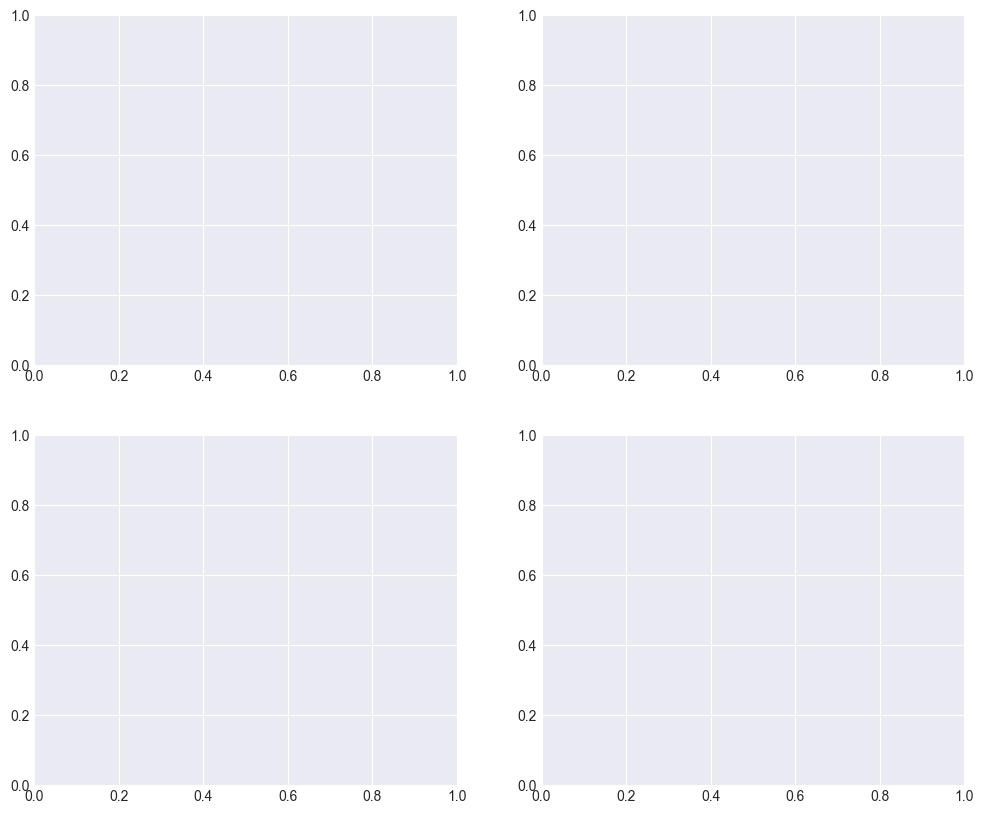

In [34]:
# Plot Fama returns comparison
if fama_original is not None and fama_new is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # FF returns - mu factor
    axes[0, 0].plot(fama_original['ff_returns'][:, 0], label='Original', alpha=0.7)
    axes[0, 0].plot(fama_new['ff_returns'][:, 0], label='New', alpha=0.7, linestyle='--')
    axes[0, 0].set_title('Fama-French: mu factor')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # FF returns - xi factor
    axes[0, 1].plot(fama_original['ff_returns'][:, 1], label='Original', alpha=0.7)
    axes[0, 1].plot(fama_new['ff_returns'][:, 1], label='New', alpha=0.7, linestyle='--')
    axes[0, 1].set_title('Fama-French: xi factor')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # FM returns - mu factor
    axes[1, 0].plot(fama_original['fm_returns'][:, 0], label='Original', alpha=0.7)
    axes[1, 0].plot(fama_new['fm_returns'][:, 0], label='New', alpha=0.7, linestyle='--')
    axes[1, 0].set_title('Fama-MacBeth: mu factor')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # FM returns - xi factor
    axes[1, 1].plot(fama_original['fm_returns'][:, 1], label='Original', alpha=0.7)
    axes[1, 1].plot(fama_new['fm_returns'][:, 1], label='New', alpha=0.7, linestyle='--')
    axes[1, 1].set_title('Fama-MacBeth: xi factor')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot DKKM factors comparison
if dkkm_original is not None and dkkm_new is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Rank standardized - factor 1
    axes[0, 0].plot(dkkm_original['factors_rs'][:, 0], label='Original', alpha=0.7)
    axes[0, 0].plot(dkkm_new['factors_rs'][:, 0], label='New', alpha=0.7, linestyle='--')
    axes[0, 0].set_title('DKKM (rank std): factor 1')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Rank standardized - factor 2
    axes[0, 1].plot(dkkm_original['factors_rs'][:, 1], label='Original', alpha=0.7)
    axes[0, 1].plot(dkkm_new['factors_rs'][:, 1], label='New', alpha=0.7, linestyle='--')
    axes[0, 1].set_title('DKKM (rank std): factor 2')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # No rank standardization - factor 1
    axes[1, 0].plot(dkkm_original['factors_nors'][:, 0], label='Original', alpha=0.7)
    axes[1, 0].plot(dkkm_new['factors_nors'][:, 0], label='New', alpha=0.7, linestyle='--')
    axes[1, 0].set_title('DKKM (no rank std): factor 1')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # No rank standardization - factor 2
    axes[1, 1].plot(dkkm_original['factors_nors'][:, 1], label='Original', alpha=0.7)
    axes[1, 1].plot(dkkm_new['factors_nors'][:, 1], label='New', alpha=0.7, linestyle='--')
    axes[1, 1].set_title('DKKM (no rank std): factor 2')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()